In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [4]:
df = pd.read_csv(r"C:\Users\USER\Music\sales_pipeline.csv")
df = pd.DataFrame(df)

In [5]:
#Membaca data
print(df.head())
print(df.columns.tolist())

  opportunity_id      sales_agent         product  account deal_stage  \
0       1C1I7A6R      Moses Frase  GTX Plus Basic  Cancity        Won   
1       Z063OYW0  Darcel Schlecht          GTXPro    Isdom        Won   
2       EC4QE1BX  Darcel Schlecht      MG Special  Cancity        Won   
3       MV1LWRNH      Moses Frase       GTX Basic  Codehow        Won   
4       PE84CX4O        Zane Levy       GTX Basic   Hatfan        Won   

  engage_date  close_date  close_value  
0  2016-10-20  2017-03-01       1054.0  
1  2016-10-25  2017-03-11       4514.0  
2  2016-10-25  2017-03-07         50.0  
3  2016-10-25  2017-03-09        588.0  
4  2016-10-25  2017-03-02        517.0  
['opportunity_id', 'sales_agent', 'product', 'account', 'deal_stage', 'engage_date', 'close_date', 'close_value']


In [6]:
#Pembersihan data
df.isnull().sum()

opportunity_id       0
sales_agent          0
product              0
account           1425
deal_stage           0
engage_date        500
close_date        2089
close_value       2089
dtype: int64

In [8]:
df["account"].head(20)

0                          Cancity
1                            Isdom
2                          Cancity
3                          Codehow
4                           Hatfan
5                         Ron-tech
6                          J-Texon
7                           Cheers
8                         Zumgoity
9                              NaN
10                      Bioholding
11    Genco Pura Olive Oil Company
12                      Sunnamplex
13                          Sonron
14                          Finjob
15                          Sonron
16                        Scotfind
17                       Treequote
18                        Xx-zobam
19                        Rantouch
Name: account, dtype: str

In [9]:
df["account"].fillna("Uknown_Company")

0              Cancity
1                Isdom
2              Cancity
3              Codehow
4               Hatfan
             ...      
8795    Uknown_Company
8796    Uknown_Company
8797    Uknown_Company
8798    Uknown_Company
8799    Uknown_Company
Name: account, Length: 8800, dtype: str

In [12]:
df.dtypes

opportunity_id        str
sales_agent           str
product               str
account               str
deal_stage            str
engage_date           str
close_date            str
close_value       float64
dtype: object

In [13]:
df["close_date"].head()

0    2017-03-01
1    2017-03-11
2    2017-03-07
3    2017-03-09
4    2017-03-02
Name: close_date, dtype: str

In [14]:
df = df.dropna()

In [15]:
df.describe()

,close_value
count,6711.000000
mean,1490.915512
std,2320.670773
min,0.000000
25%,0.000000
50%,472.000000
75%,3225.000000
max,30288.000000


In [23]:
df["total_agents"] = (df["sales_agent"]).count()
df["successful_sell"] = np.where((df["deal_stage"] == "Won"), df["opportunity_id"], np.nan)

In [24]:
df["Total_sales"] = df["successful_sell"].count()

In [39]:
total_sales_GTXPlusBasic = int(df[
                                (df["product"] == 'GTX Plus Basic')
                                & (df["successful_sell"] == df["opportunity_id"])]["product"].count())

In [42]:
print(total_sales_GTXPlusBasic)

653


In [44]:
total_sales_GTXPro = int(df[
                                (df["product"] == 'GTXPro')
                                & (df["successful_sell"] == df["opportunity_id"])]["product"].count())

In [45]:
total_sales_MGSpecial = int(df[
                                (df["product"] == 'MG Special')
                                & (df["successful_sell"] == df["opportunity_id"])]["product"].count())

In [46]:
total_sales_GTXBasic = int(df[
                                (df["product"] == 'GTX Basic')
                                & (df["successful_sell"] == df["opportunity_id"])]["product"].count())

In [56]:
total_sales_GTXPlusPro = int(df[
                                (df["product"] == 'GTX Plus Pro')
                                & (df["successful_sell"] == df["opportunity_id"])]["product"].count())

In [57]:
total_sales_MGAdvanced = int(df[
                                (df["product"] == 'MG Advanced')
                                & (df["successful_sell"] == df["opportunity_id"])]["product"].count())

In [58]:
total_sales_Gtk500 = int(df[
                                (df["product"] == 'GTK 500')
                                & (df["successful_sell"] == df["opportunity_id"])]["product"].count())

In [59]:
total_sales = sum([total_sales_GTXPlusBasic, total_sales_GTXPro, 
                     total_sales_MGSpecial, total_sales_GTXBasic, total_sales_GTXPlusPro, 
                     total_sales_MG_advanced, total_sales_Gtk500])

In [60]:
#Eksplorasi Data
persentase_penjualan_produkgtxplusbasic = total_sales_GTXPlusBasic/total_sales*100
persentase_penjualan_produkmgspecial = total_sales_MGSpecial/total_sales*100
persentase_penjualan_produkgtxpro = total_sales_GTXPro/total_sales*100
persentase_penjualan_produkgtxbasic = total_sales_GTXBasic/total_sales*100
persentase_penjualan_produkgtxpluspro = total_sales_GTXPlusPro/total_sales*100
persentase_penjualan_produkmgadvanced = total_sales_MGAdvanced/total_sales*100
persentase_penjualan_produkgtk500 = total_sales_Gtk500/total_sales*100

In [65]:
df["kecepatan_penjualan"] = (pd.to_datetime(df["close_date"]) - pd.to_datetime(df["engage_date"]))

In [67]:
df["kecepatan_penjualan"]

0      132 days
1      137 days
2      133 days
3      135 days
4      128 days
         ...   
8295     2 days
8296     6 days
8297     3 days
8298     3 days
8299     2 days
Name: kecepatan_penjualan, Length: 6711, dtype: timedelta64[us]

In [89]:
total_penjualan_sales = df[df["deal_stage"] == "Won"]["sales_agent"].value_counts().to_dict()
penjualan_cepat = df[df["kecepatan_penjualan"] <= timedelta(days=100)]["sales_agent"].value_counts().to_dict()

In [79]:
print(total_penjualan_sales)

{'Darcel Schlecht': 349, 'Vicki Laflamme': 221, 'Kary Hendrixson': 209, 'Anna Snelling': 208, 'Versie Hillebrand': 176, 'Kami Bicknell': 174, 'Jonathan Berthelot': 171, 'Cassey Cress': 163, 'Zane Levy': 161, 'Donn Cantrell': 158, 'Reed Clapper': 155, 'Corliss Cosme': 150, 'Maureen Marcano': 149, 'James Ascencio': 135, 'Gladys Colclough': 135, 'Markita Hansen': 130, 'Moses Frase': 129, 'Lajuana Vencill': 127, 'Violet Mclelland': 122, 'Marty Freudenburg': 122, 'Daniell Hammack': 114, 'Hayden Neloms': 107, 'Cecily Lampkin': 107, 'Niesha Huffines': 105, 'Boris Faz': 101, 'Elease Gluck': 80, 'Rosie Papadopoulos': 78, 'Garret Kinder': 75, 'Rosalina Dieter': 72, 'Wilburn Farren': 55}


In [104]:
print(penjualan_cepat)

{'Darcel Schlecht': 491, 'Vicki Laflamme': 305, 'Kary Hendrixson': 299, 'Anna Snelling': 294, 'Donn Cantrell': 245, 'Zane Levy': 237, 'Kami Bicknell': 234, 'Cassey Cress': 228, 'Versie Hillebrand': 228, 'Jonathan Berthelot': 225, 'Gladys Colclough': 208, 'Reed Clapper': 208, 'Lajuana Vencill': 200, 'Corliss Cosme': 198, 'Markita Hansen': 195, 'Maureen Marcano': 184, 'James Ascencio': 183, 'Daniell Hammack': 168, 'Marty Freudenburg': 164, 'Moses Frase': 162, 'Violet Mclelland': 161, 'Cecily Lampkin': 148, 'Niesha Huffines': 142, 'Boris Faz': 137, 'Hayden Neloms': 131, 'Elease Gluck': 111, 'Garret Kinder': 110, 'Rosie Papadopoulos': 105, 'Rosalina Dieter': 97, 'Wilburn Farren': 67}


In [105]:
penjualan_gagal_setiap_produk = df[df["deal_stage"] == "Lost"]["product"].value_counts().to_dict()
penjualan_berhasil_setiap_produk = df[df["deal_stage"] == "Won"]["product"].value_counts().to_dict()
print(penjualan_gagal_setiap_produk)
print(penjualan_berhasil_setiap_produk)

{'GTX Basic': 521, 'MG Special': 430, 'MG Advanced': 430, 'GTXPro': 418, 'GTX Plus Basic': 398, 'GTX Plus Pro': 266, 'GTK 500': 10}
{'GTX Basic': 915, 'MG Special': 793, 'GTXPro': 729, 'MG Advanced': 654, 'GTX Plus Basic': 653, 'GTX Plus Pro': 479, 'GTK 500': 15}


<Axes: >

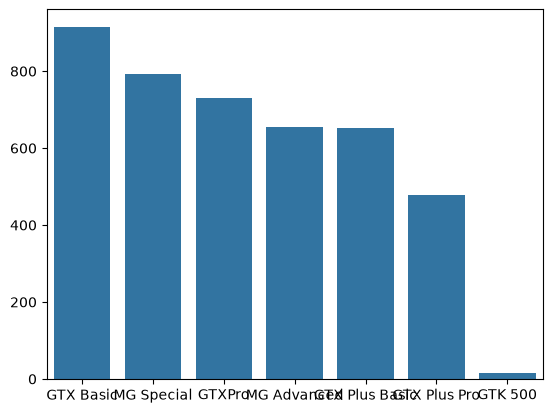

In [107]:
x = penjualan_berhasil_setiap_produk.keys()
y = penjualan_berhasil_setiap_produk.values()
sns.barplot(x = x, y = y)
